In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [2]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)

In [3]:
label_df_filtered = label_df.copy()
label_df_filtered[(label_df_filtered["dom_label"] == 0.0) & (label_df_filtered["label"] == 1)]["label"] = -1
label_df_filtered[(label_df_filtered["dom_label"] > 0.0) & (label_df_filtered["label"] == -1)]["label"] = 1
label_df_filtered = label_df_filtered[label_df["label"] >= 0]
print(label_df_filtered["label"].value_counts())


/tmp/ipykernel_188899/1181249941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_df_filtered[(label_df_filtered["dom_label"] == 0.0) & (label_df_filtered["label"] == 1)]["label"] = -1
/tmp/ipykernel_188899/1181249941.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  label_df_filtered[(label_df_filtered["dom_label"] > 0.0) & (label_df_filtered["label"] == -1)]["label"] = 1


label
0    18399879
1      101872
Name: count, dtype: int64


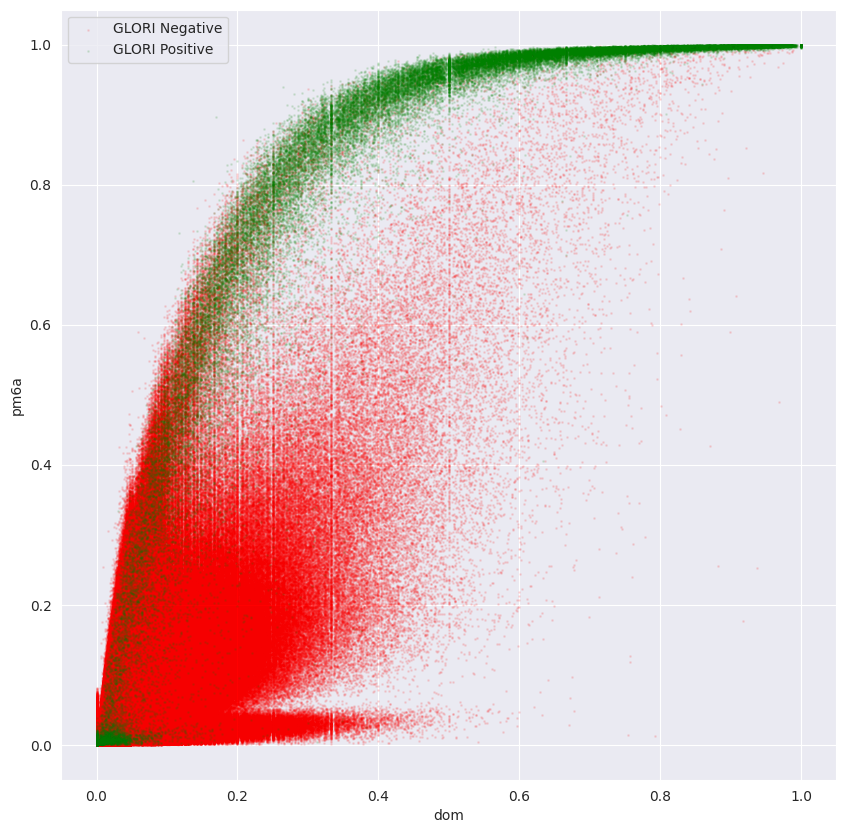

In [142]:
cell_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v2-20240827-175235-22-373000-token_normalise_dwell_all_npz-ON0090_allmotif_pileup_test/pileup_v7.pkl"
cell_df = pd.read_pickle(cell_df)
cell_df = cell_df[cell_df["count_pm6a"] >= 20]
cell_label_df = cell_df.merge(label_df_filtered, on="label_id", how="inner")

neg_df = cell_label_df[cell_label_df["dom_label"] == 0]
pos_df = cell_label_df[cell_label_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a"], alpha=0.1, s = 1, color="red", label="GLORI Negative")
ax.scatter(pos_df["dom"], pos_df["pm6a"], alpha=0.1, s = 1, color="green", label="GLORI Positive")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()
plt.close()

In [143]:
cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["dom"])) * (0.02 ** (cell_label_df["dom"])))
cell_label_df["discarded_ratio"] = (cell_label_df["count_dom"] - cell_label_df["count_pm6a"]) / cell_label_df["count_dom"]
selected_df = cell_label_df[cell_label_df["pm6a"] > cell_label_df["threshold"]]

In [108]:
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]
neg_df = neg_df[neg_df["pm6a"] > 0.8]
pos_df = pos_df[pos_df["pm6a"] > 0.8]


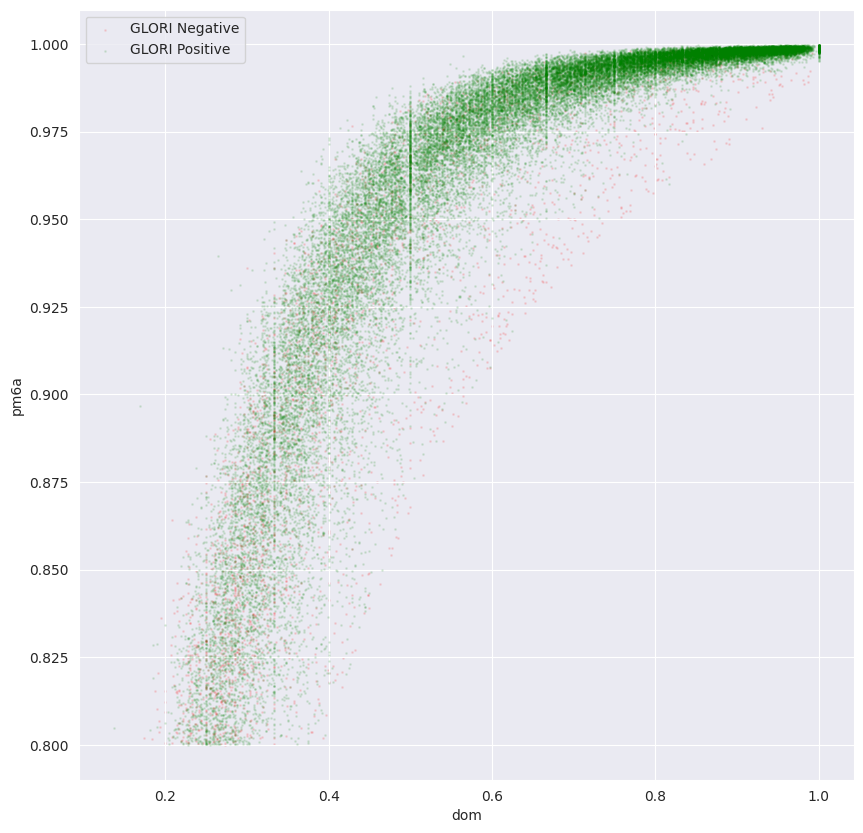

In [109]:

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a"], alpha=0.1, s = 1, color="red", label="GLORI Negative", zorder=0)
ax.scatter(pos_df["dom"], pos_df["pm6a"], alpha=0.1, s = 1, color="green", label="GLORI Positive", zorder=5)
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()
plt.close()

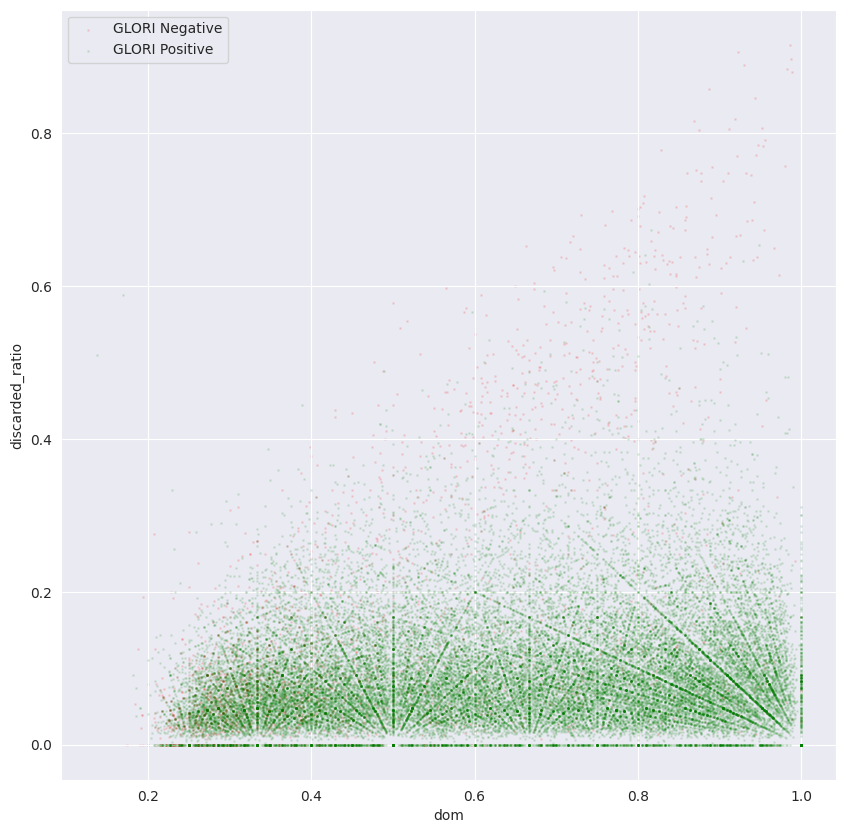

In [110]:

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["discarded_ratio"], alpha=0.1, s = 1, color="red", label="GLORI Negative", zorder=0)
ax.scatter(pos_df["dom"], pos_df["discarded_ratio"], alpha=0.1, s = 1, color="green", label="GLORI Positive", zorder=5)
ax.legend() 
ax.set_xlabel("dom")
ax.set_ylabel("discarded_ratio")
plt.show()
plt.close()

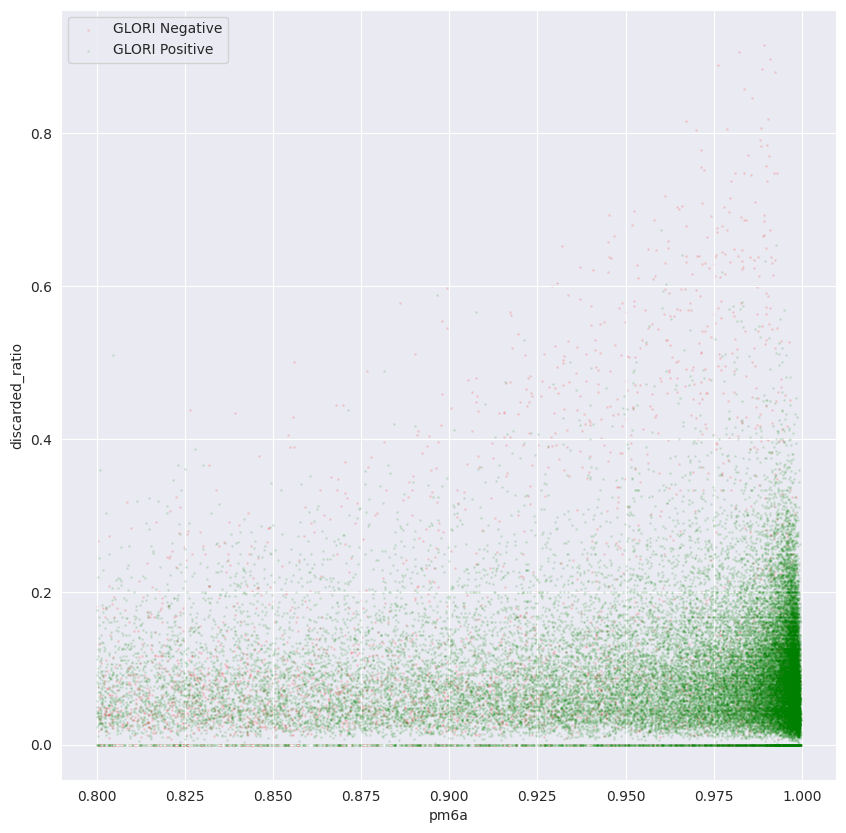

In [111]:

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["pm6a"], neg_df["discarded_ratio"], alpha=0.1, s = 1, color="red", label="GLORI Negative", zorder=0)
ax.scatter(pos_df["pm6a"], pos_df["discarded_ratio"], alpha=0.1, s = 1, color="green", label="GLORI Positive", zorder=5)
ax.legend()
ax.set_xlabel("pm6a")
ax.set_ylabel("discarded_ratio")
plt.show()
plt.close()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


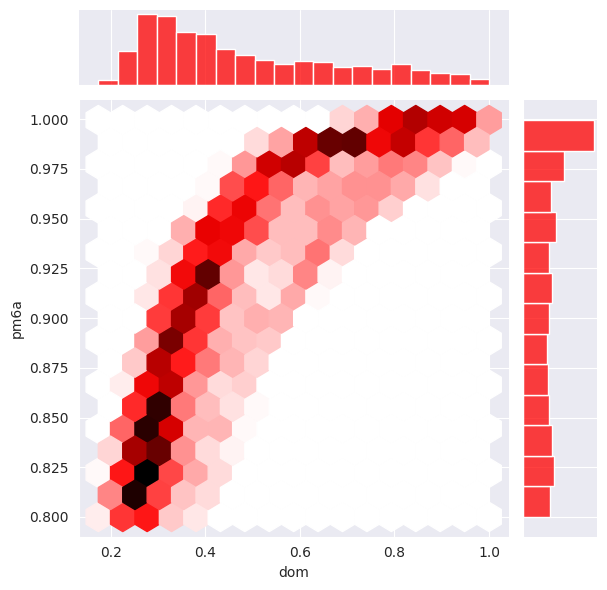

In [114]:

sns.jointplot(data=neg_df, x="dom", y="pm6a", kind="hex", color="red", label="GLORI Negative")
plt.show()
plt.close()


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


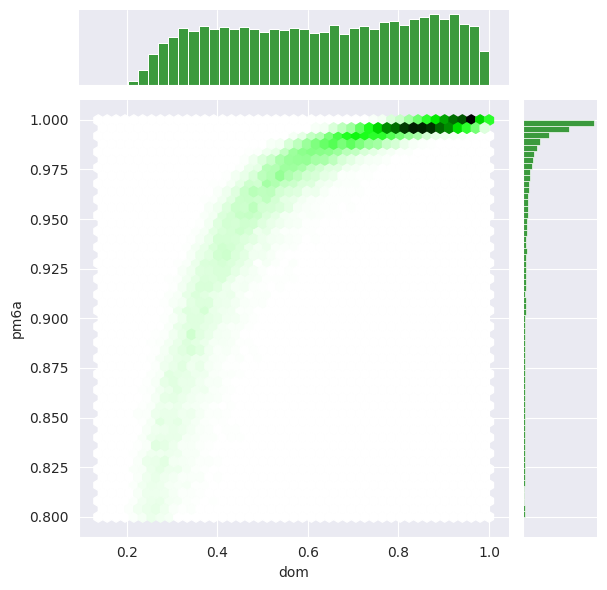

In [115]:

sns.jointplot(data=pos_df, x="dom", y="pm6a", kind="hex", color="green", label="GLORI Positive")
plt.show()
plt.close()


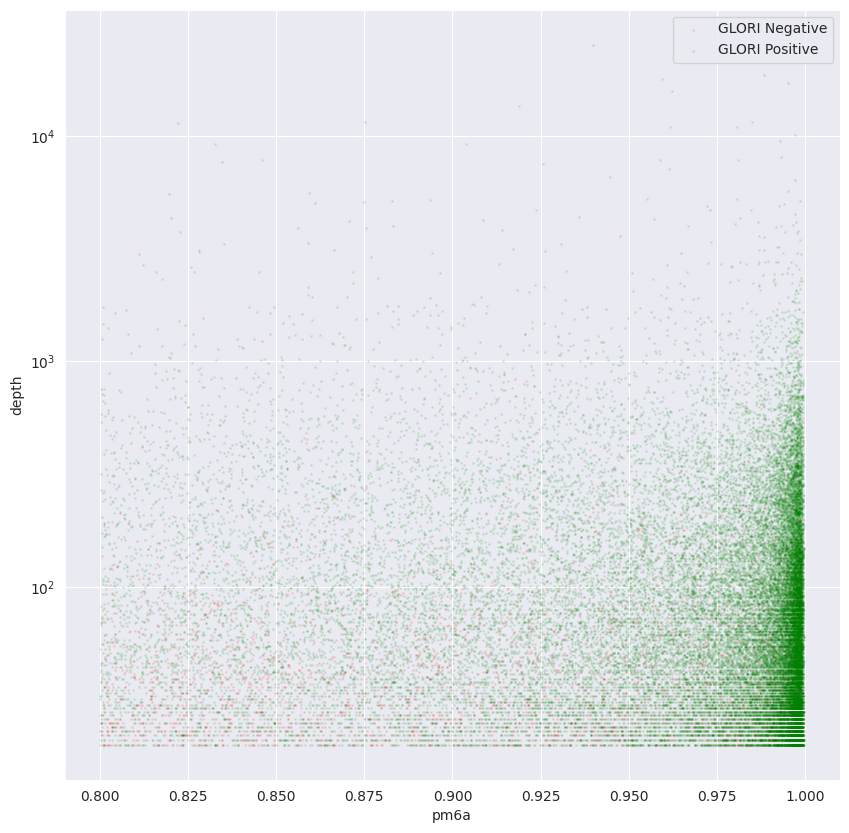

In [112]:

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["pm6a"], neg_df["count_pm6a"], alpha=0.1, s = 1, color="red", label="GLORI Negative", zorder=0)
ax.scatter(pos_df["pm6a"], pos_df["count_pm6a"], alpha=0.1, s = 1, color="green", label="GLORI Positive", zorder=5)
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("pm6a")
ax.set_ylabel("depth")
plt.show()
plt.close()

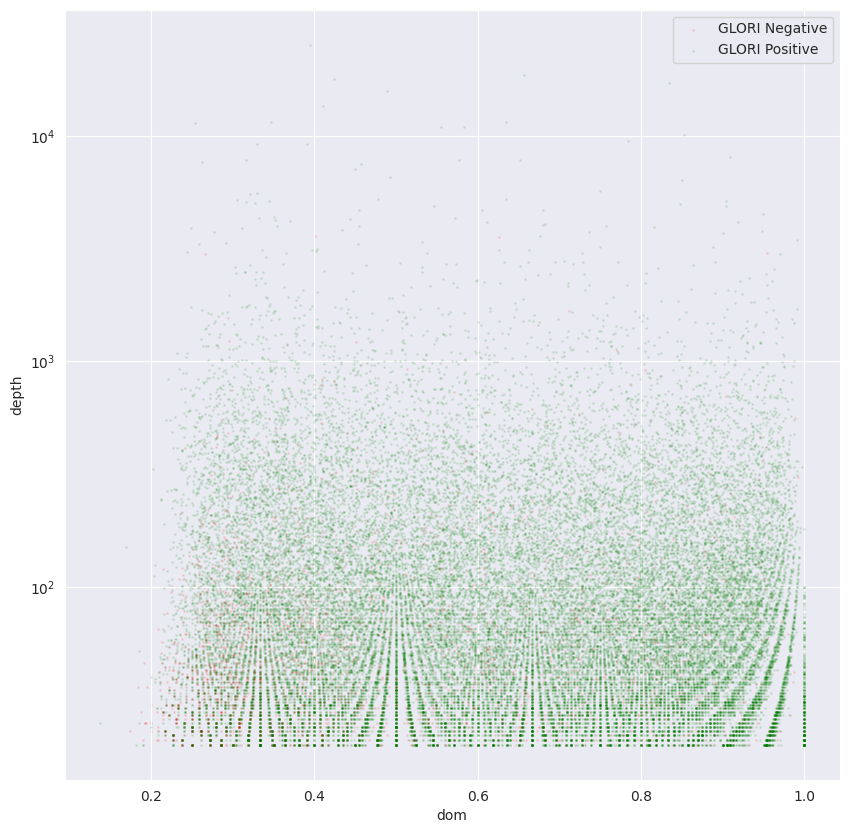

In [113]:

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["count_pm6a"], alpha=0.1, s = 1, color="red", label="GLORI Negative", zorder=0)
ax.scatter(pos_df["dom"], pos_df["count_pm6a"], alpha=0.1, s = 1, color="green", label="GLORI Positive", zorder=5)
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("dom")
ax.set_ylabel("depth")
plt.show()
plt.close()

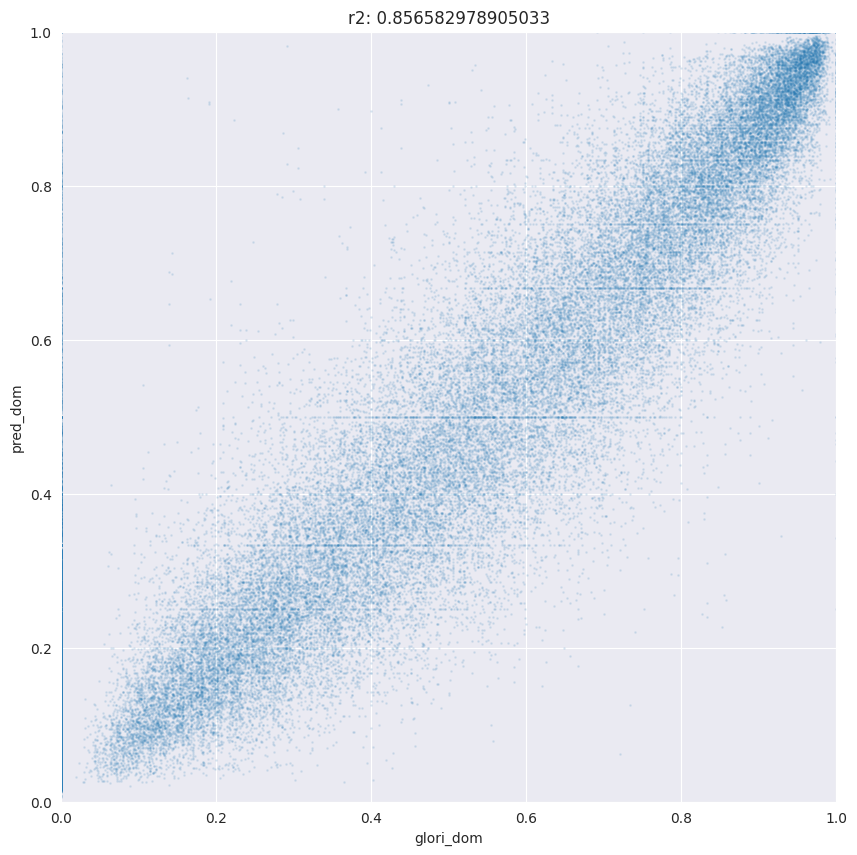

In [144]:

selected_df = cell_label_df[(cell_label_df["pm6a"] > cell_label_df["threshold"])]

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

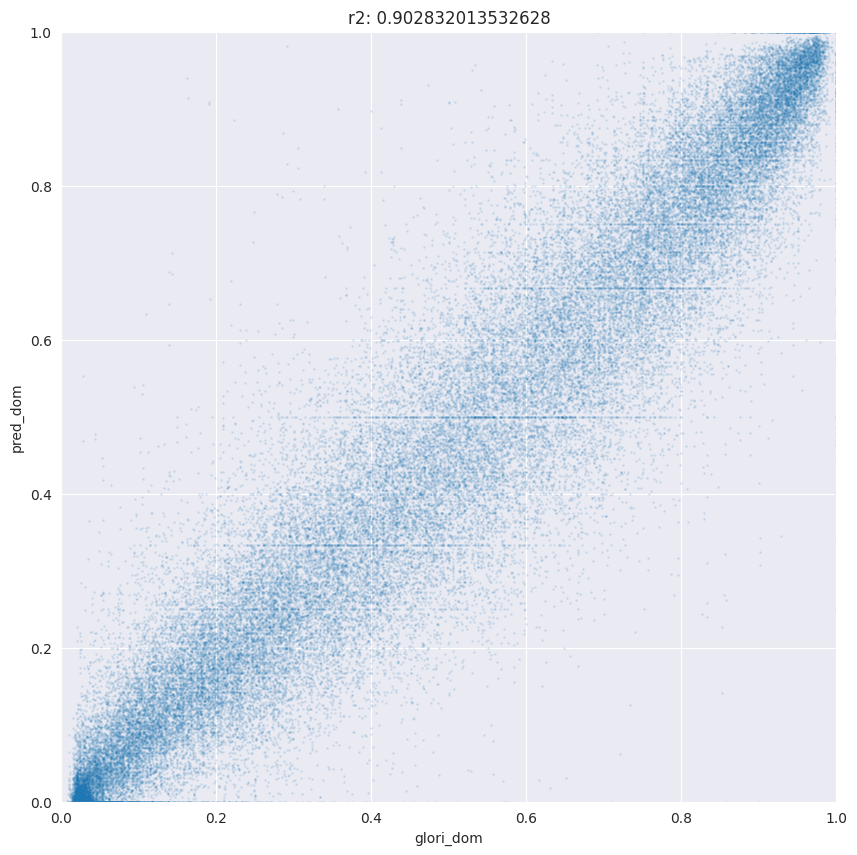

In [49]:

selected_df = cell_label_df[cell_label_df["dom_label"] > 0]

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

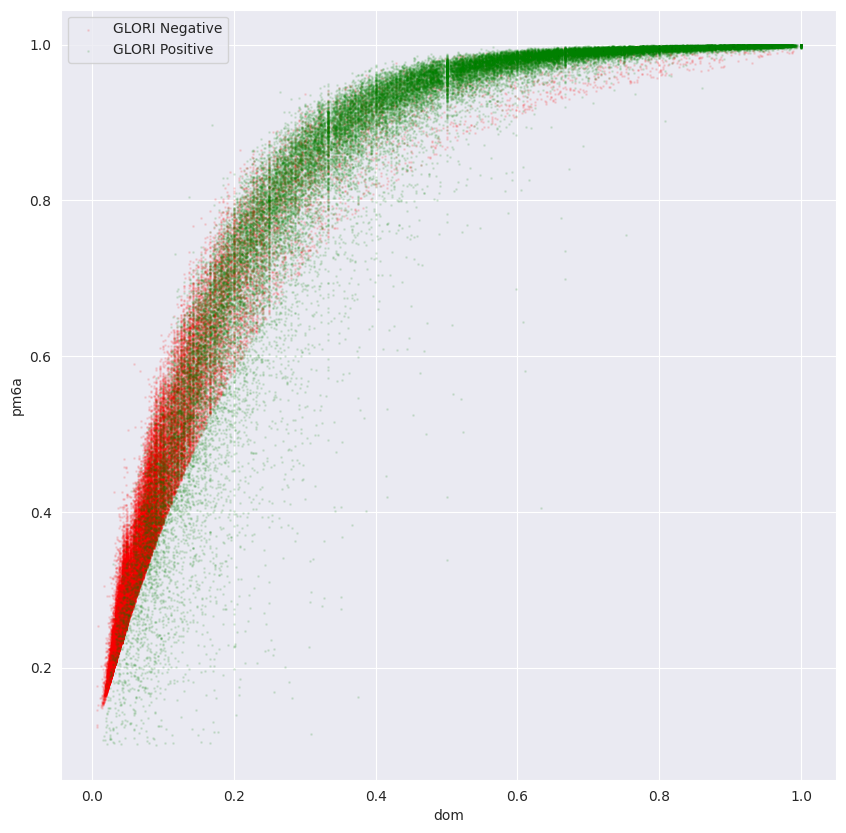

In [48]:

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a"], alpha=0.1, s = 1, color="red", label="GLORI Negative")
ax.scatter(pos_df["dom"], pos_df["pm6a"], alpha=0.1, s = 1, color="green", label="GLORI Positive")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()
plt.close()

In [145]:
from sklearn.metrics import precision_recall_curve, auc

selected_df = cell_label_df[(~cell_label_df["drach"]) & (cell_label_df["count_pm6a"] >= 100) & (cell_label_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]

In [ ]:

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.plot(recall, precision, label=f"AUC: {auc_score}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()



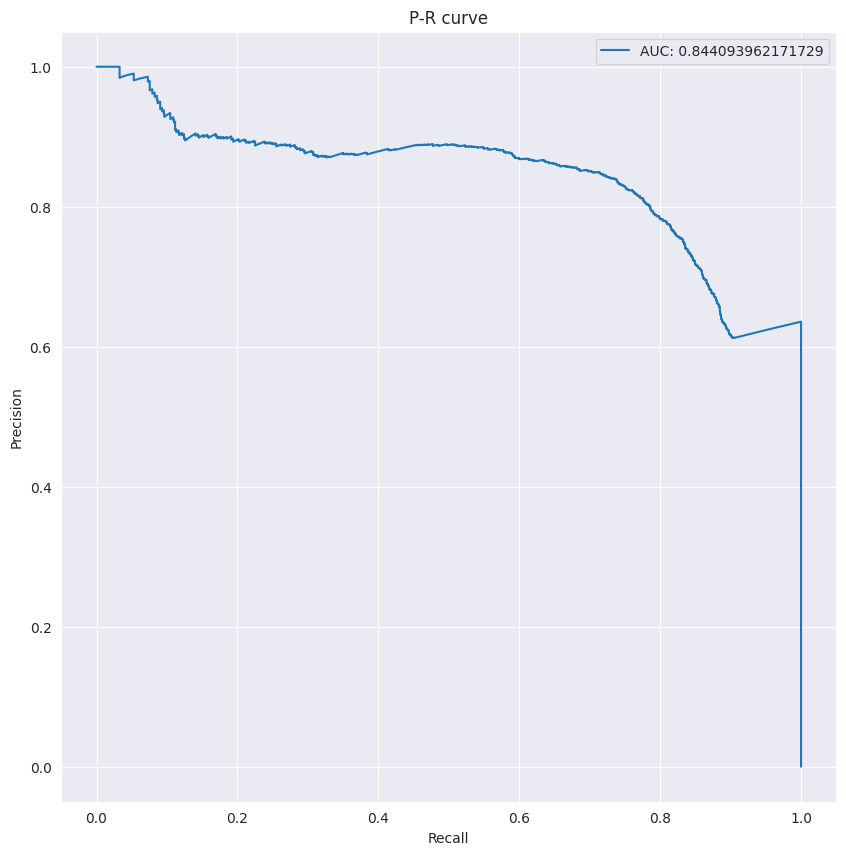

In [55]:
selected_df["pm6a_thr"] = selected_df.apply(lambda x: x["pm6a"] if ((x["pm6a"] > x["threshold"]) or (x["dom_label"] > 0)) else 0, axis=1)

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.plot(recall, precision, label=f"AUC: {auc_score}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


                label_id      pm6a  count_pm6a       dom  count_dom  \
1         NM_000016:1008  0.000804       253.0  0.000000        255   
2         NM_000016:1009  0.002531       257.0  0.000000        258   
3         NM_000016:1010  0.003011       253.0  0.011628        258   
4         NM_000016:1014  0.003508       247.0  0.003968        252   
5         NM_000016:1020  0.003651       256.0  0.003861        259   
...                  ...       ...         ...       ...        ...   
10257825   NR_182661:948  0.008162       105.0  0.000000        107   
10257826   NR_182661:951  0.002464       105.0  0.009091        110   
10257828   NR_182661:967  0.005333       107.0  0.000000        110   
10257829   NR_182661:975  0.001017       104.0  0.009434        106   
10257832   NR_182661:993  0.004101       101.0  0.018868        106   

          mean_pred  depth  label  dom_label   5mer  drach  threshold  \
1          0.001761    268      0        0.0  GGAAA  False   0.100000   
2

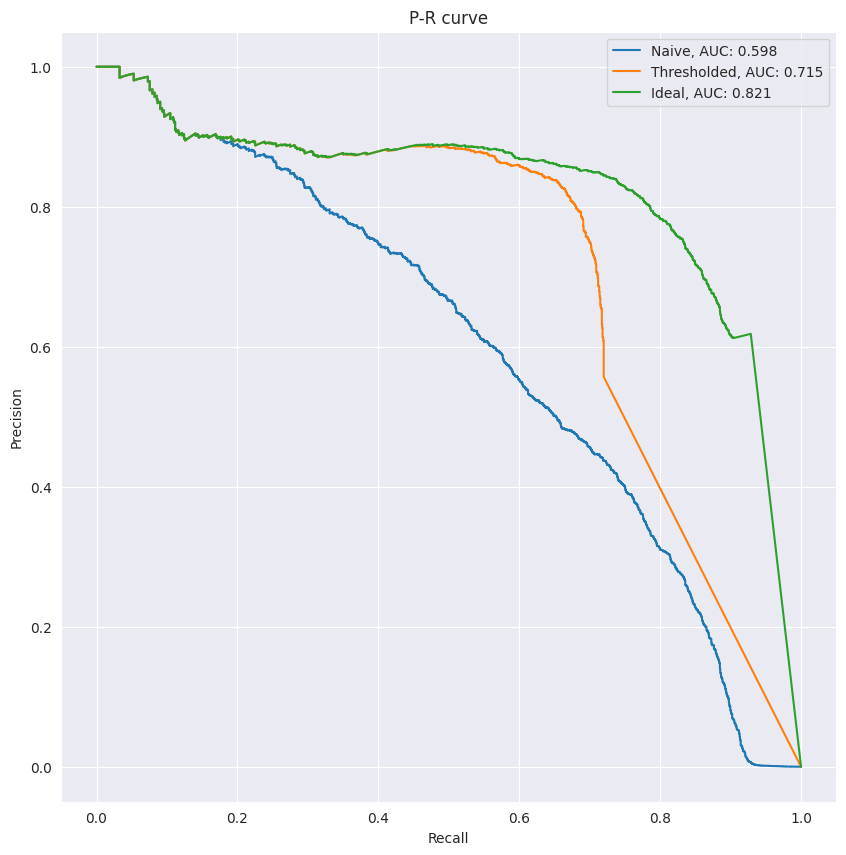

In [146]:
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))

print(selected_df)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


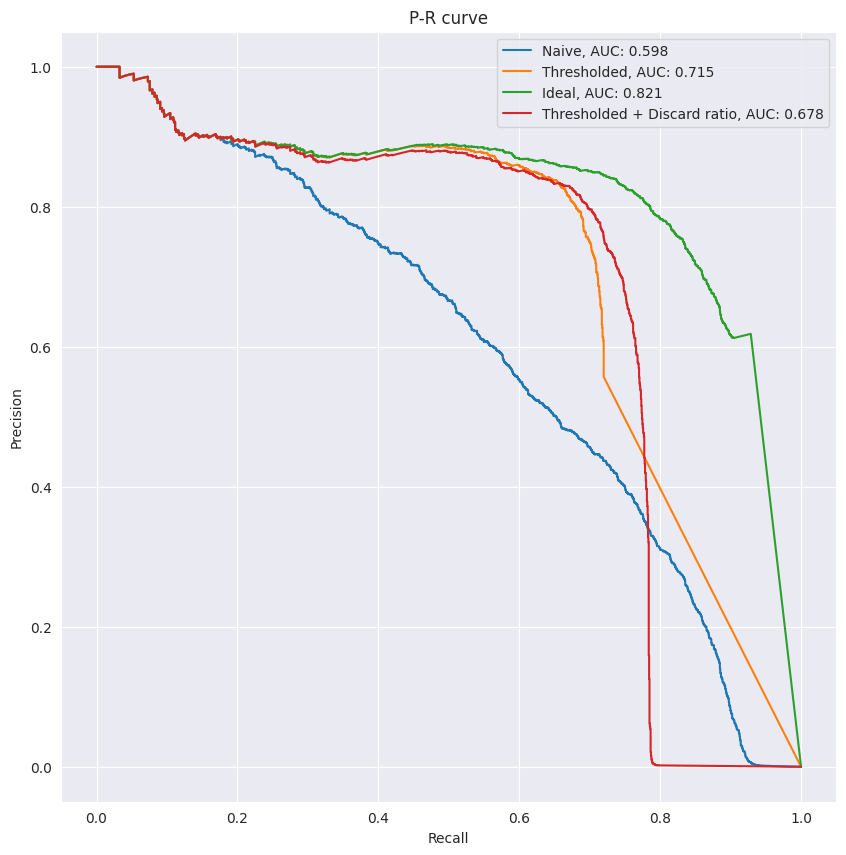

In [120]:

selected_df["threshold_v2"] = 1-(0.02 ** (selected_df["dom"]))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold_v2"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded + Discard ratio, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


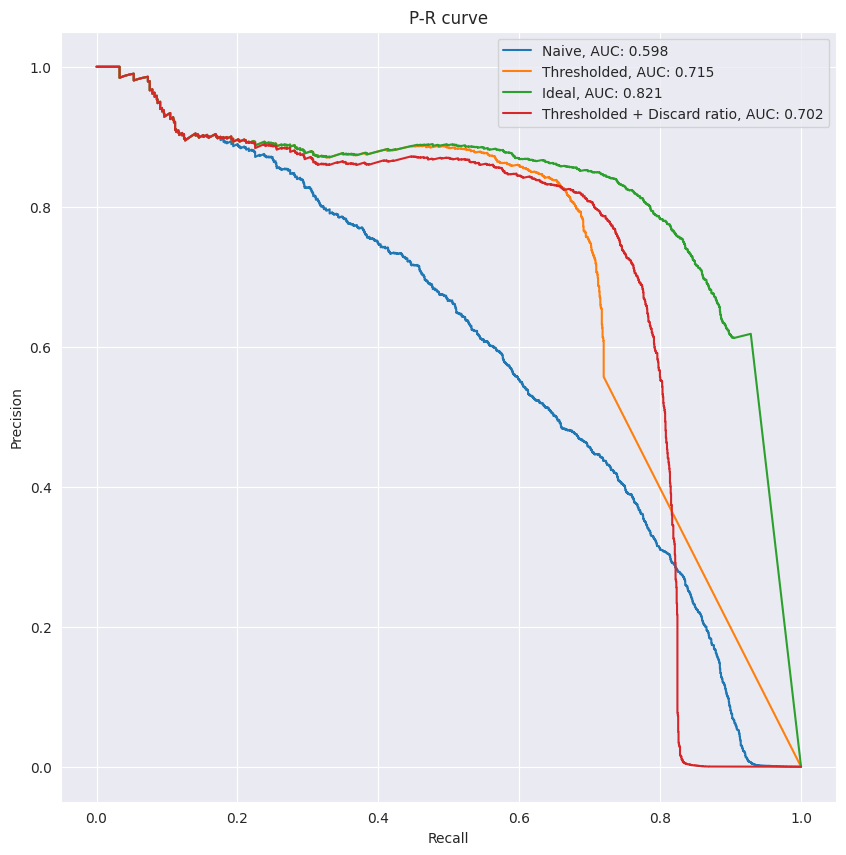

In [121]:

selected_df["threshold_v2"] = 1-((1.1 ** (1-selected_df["dom"])) * (0.02 ** (selected_df["dom"])))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold_v2"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded + Discard ratio, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


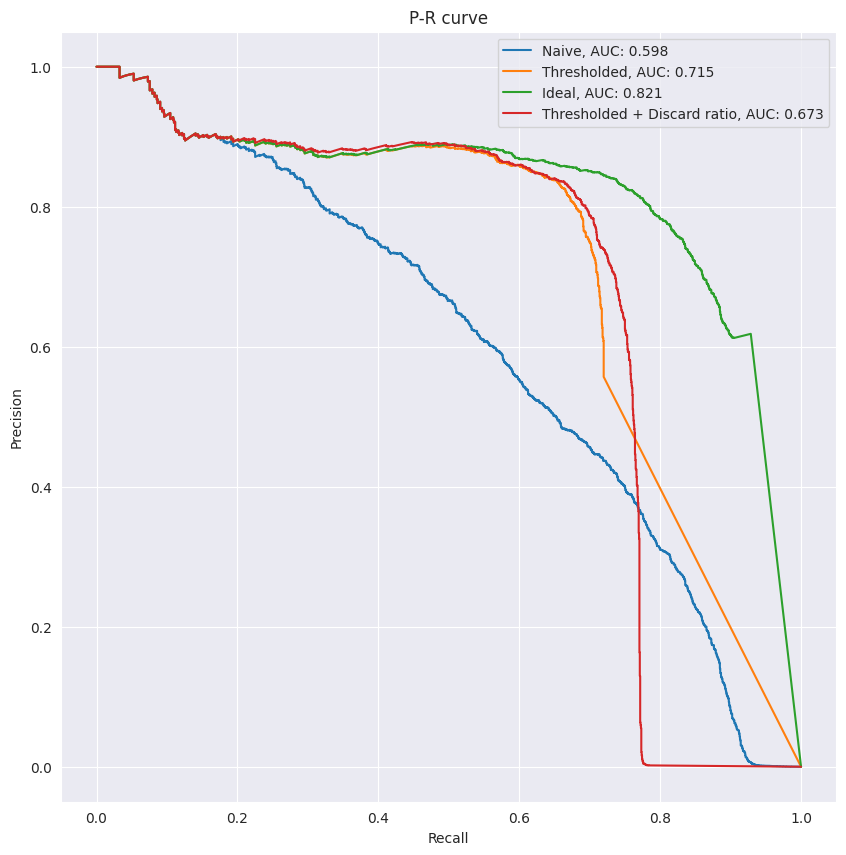

In [122]:

selected_df["threshold_v2"] = 1-((0.9 ** selected_df["dom"]) * (0.02 ** (selected_df["dom"])))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold_v2"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded + Discard ratio, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


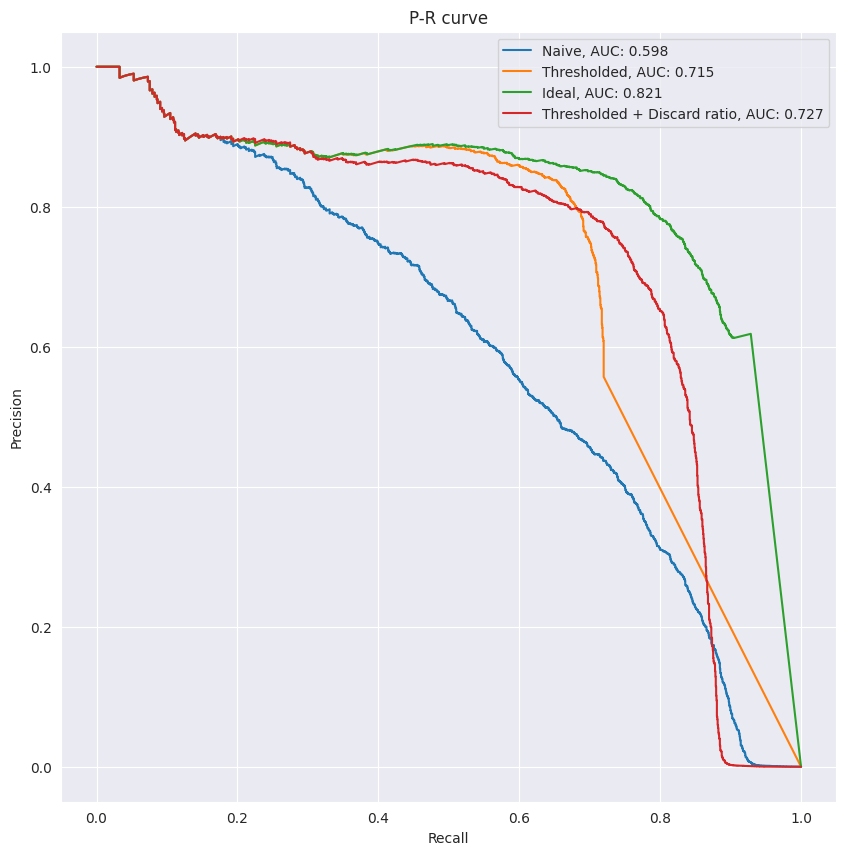

In [123]:

selected_df["threshold_v2"] = 1-(0.01 ** (selected_df["dom"]-0.1))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold_v2"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded + Discard ratio, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


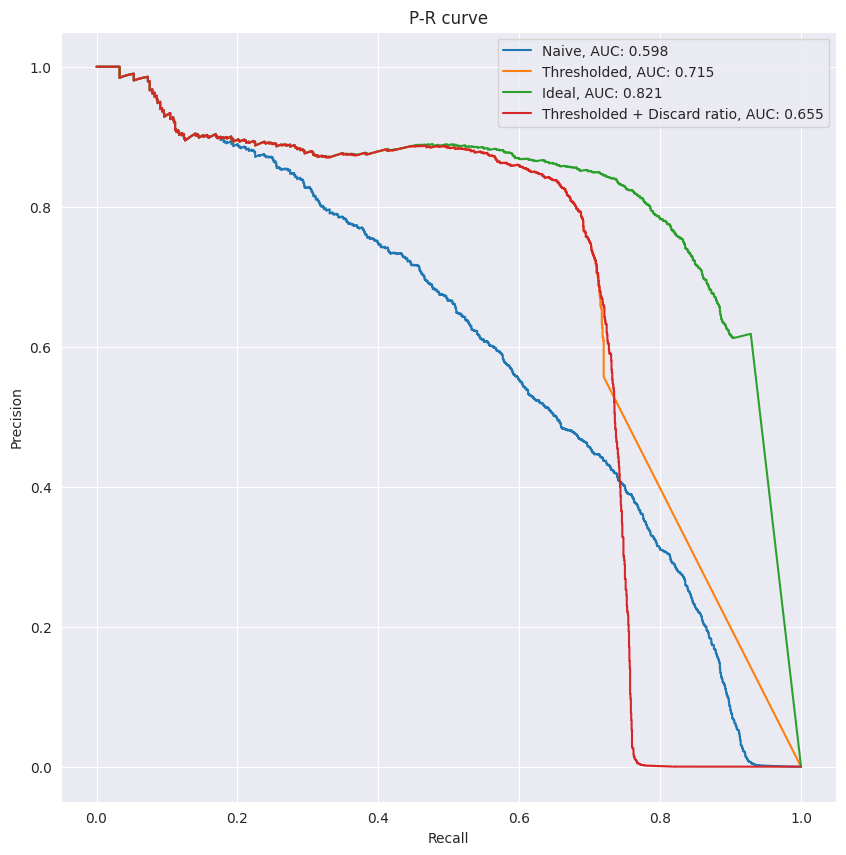

In [127]:

selected_df["threshold_v2"] = 1-(0.02 ** (selected_df["dom"]-0.1))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"])|(selected_df["dom"] < 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded + Discard ratio, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


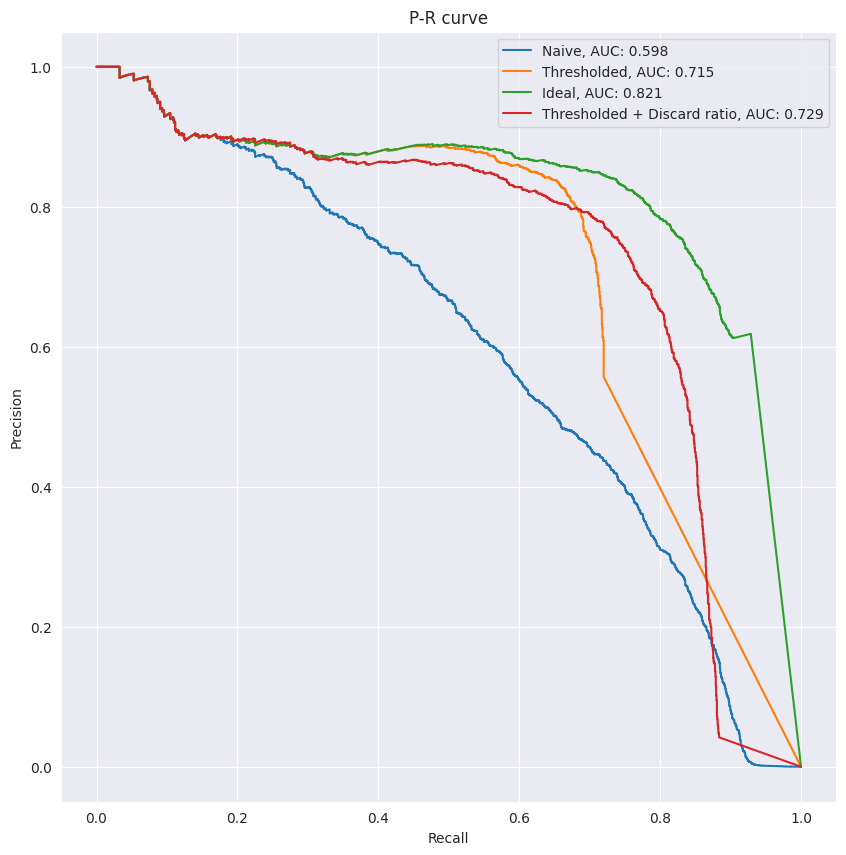

In [128]:

selected_df["threshold_v2"] = 1-(0.01 ** (selected_df["dom"]-0.1))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded + Discard ratio, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


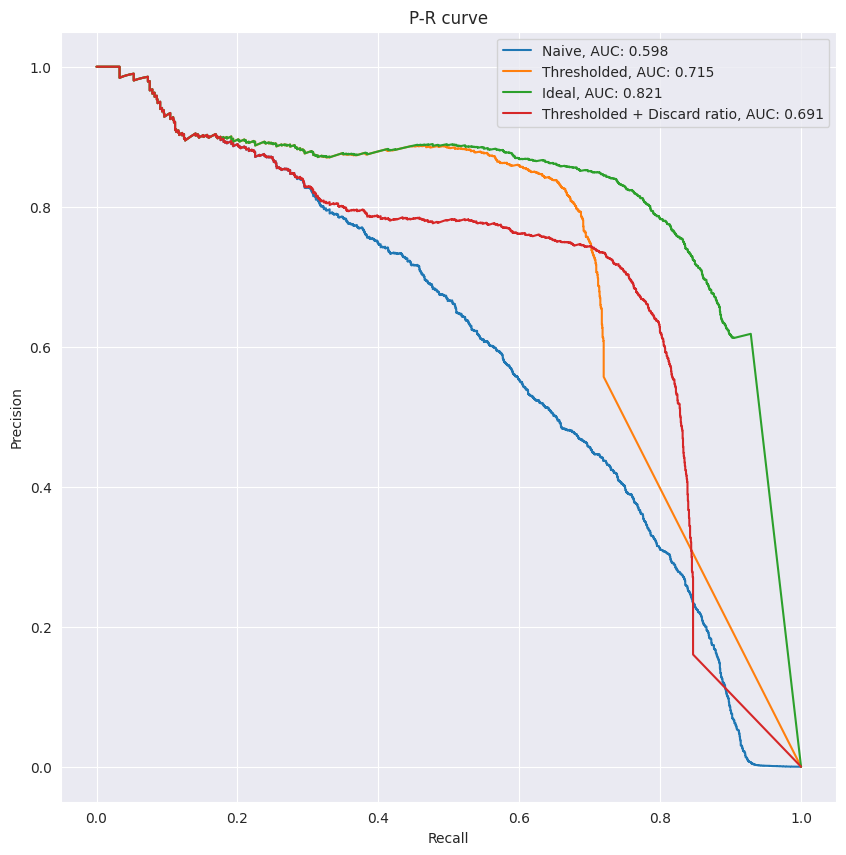

In [129]:

selected_df["threshold_v2"] = 1-((0.9 ** selected_df["dom"]) * (0.05 ** (selected_df["dom"])))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded + Discard ratio, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


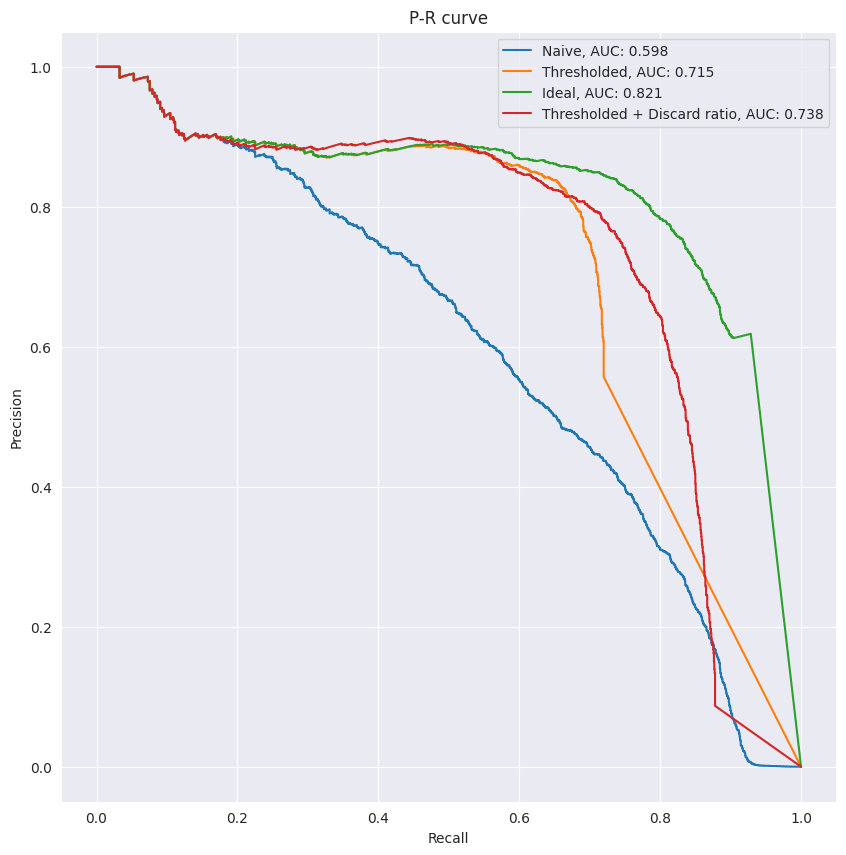

In [131]:

selected_df["threshold_v2"] = (0.85 + 0.1 * selected_df["dom"]) * (1 / (1 + 300 ** (-2 * selected_df["dom"] + 0.5)) + 0.03)
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded + Discard ratio, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


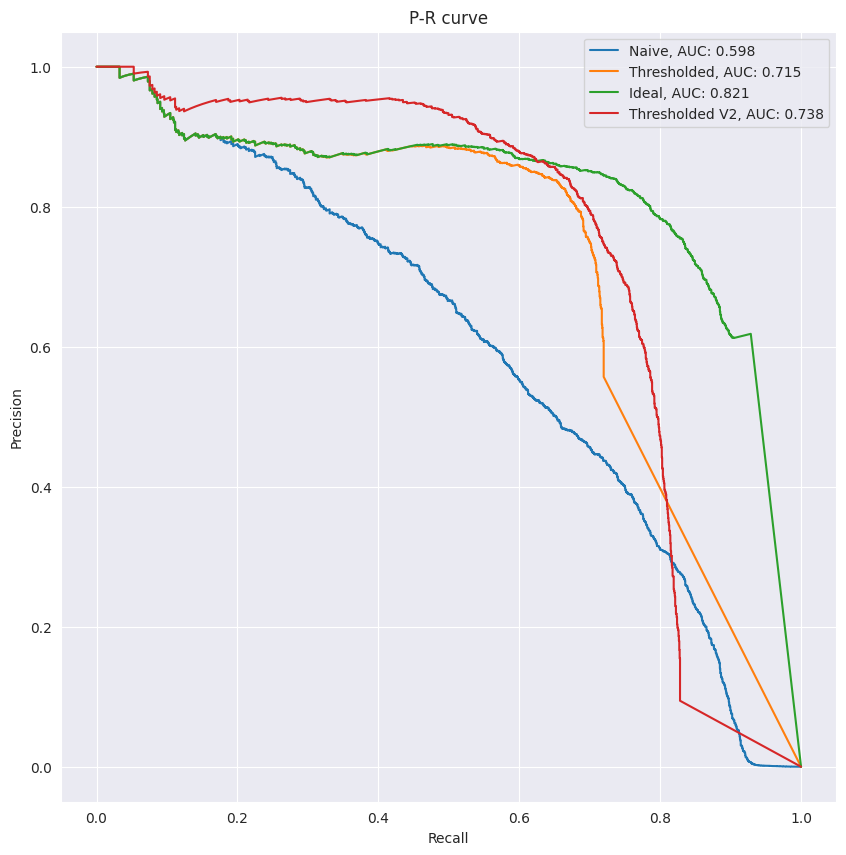

In [151]:

selected_df["threshold_v2"] = (0.9 + 0.08 * selected_df["dom"]) * (1 / (1 + 300 ** (-2.2 * selected_df["dom"] + 0.5)) + 0.02)
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded V2, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


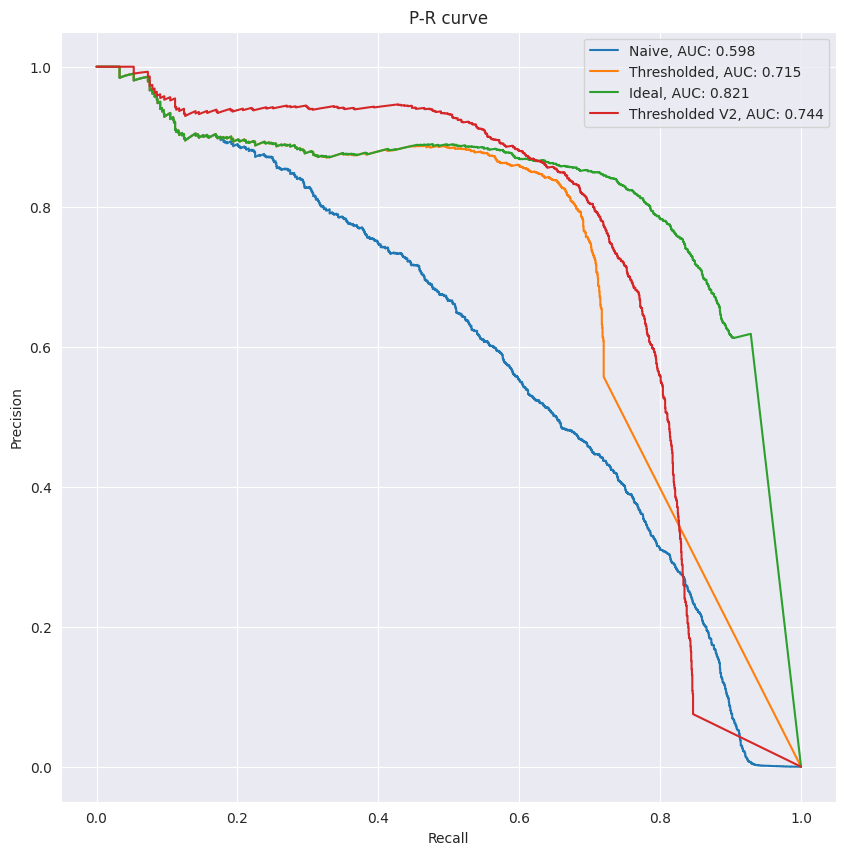

In [152]:

selected_df["threshold_v2"] = (0.9 + 0.1 * selected_df["dom"]) * (1 / (1 + 300 ** (-2.2 * selected_df["dom"] + 0.5)))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded V2, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


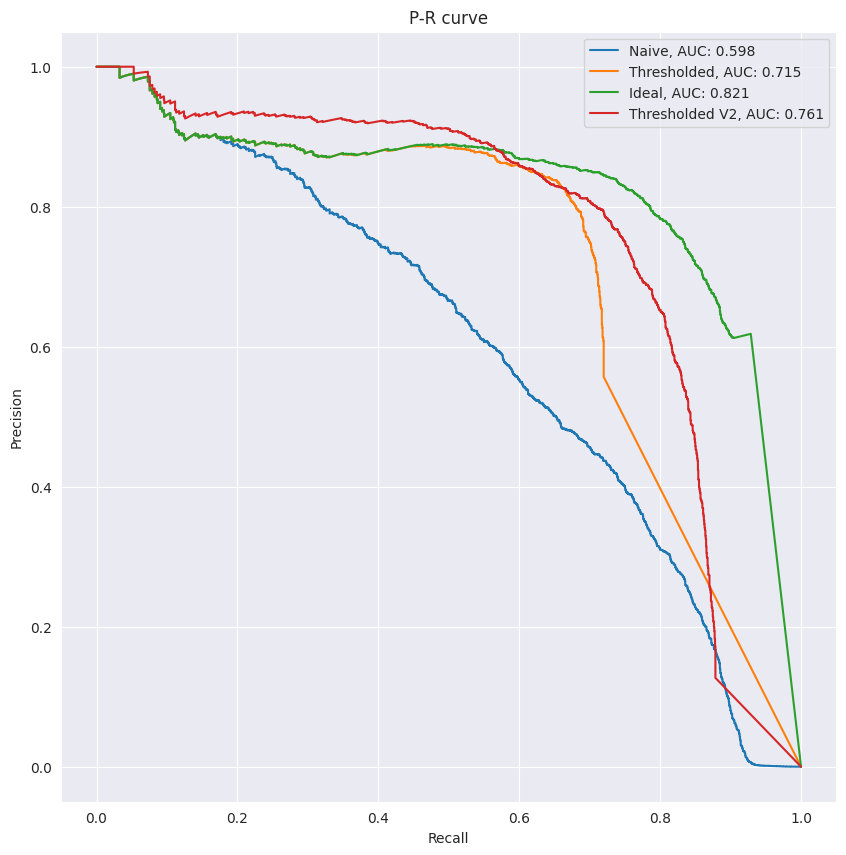

In [160]:

selected_df["threshold_v2"] = (0.9 + 0.1 * selected_df["dom"]) * (1 / (1 + 100 ** (-2 * selected_df["dom"] + 0.5)))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded V2, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


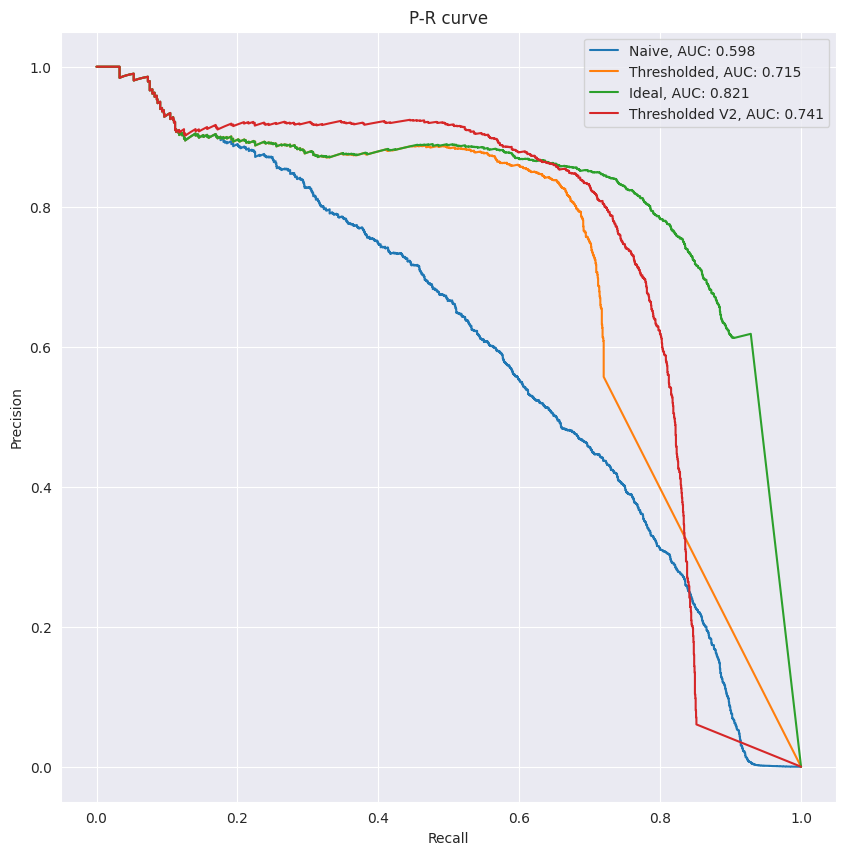

In [178]:

selected_df["threshold_v2"] = 1-((0.9 ** (1-selected_df["dom"])) * (0.01 ** (1.1*selected_df["dom"]-0.1)))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] >= selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded V2, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


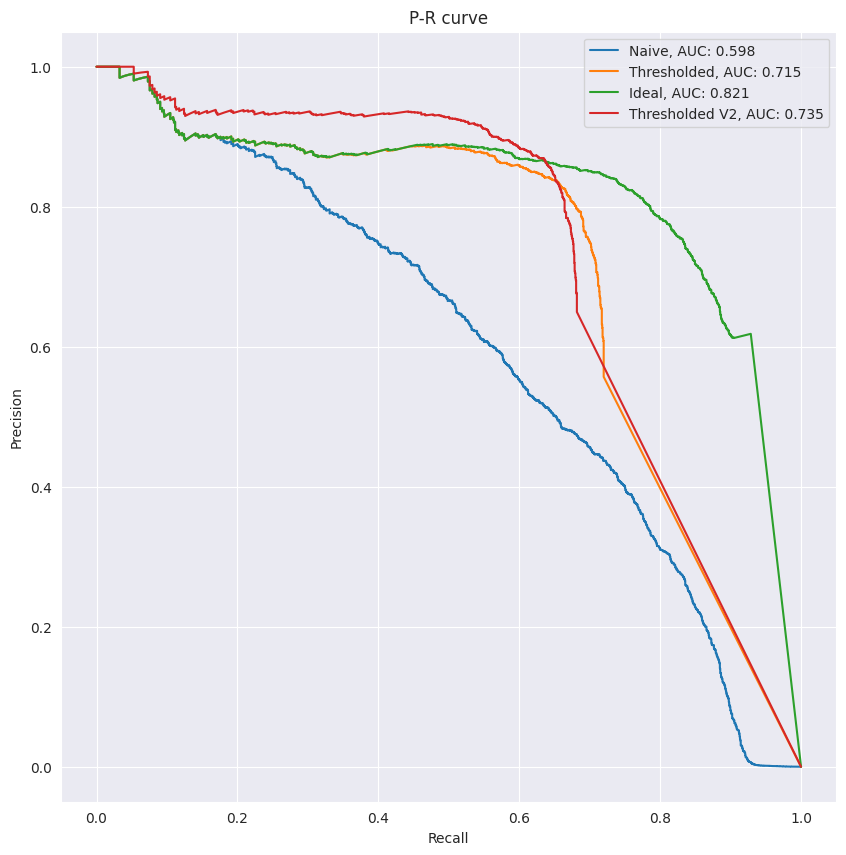

In [185]:

selected_df["threshold_v2"] = 1.02-((0.9 ** (1-selected_df["dom"])) * (0.02 ** (selected_df["dom"])))
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])
selected_df["pm6a_ideal"] = selected_df["pm6a"] * ((selected_df["pm6a"] > selected_df["threshold"]) | ((selected_df["dom_label"] > 0) & (selected_df["pm6a"] > 0.05)))
selected_df["pm6a_thr_v2"] = selected_df["pm6a"] * ((selected_df["pm6a"] >= selected_df["threshold_v2"])& (selected_df["pm6a"] > 0.1))

fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Naive, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_ideal"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Ideal, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr_v2"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Thresholded V2, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


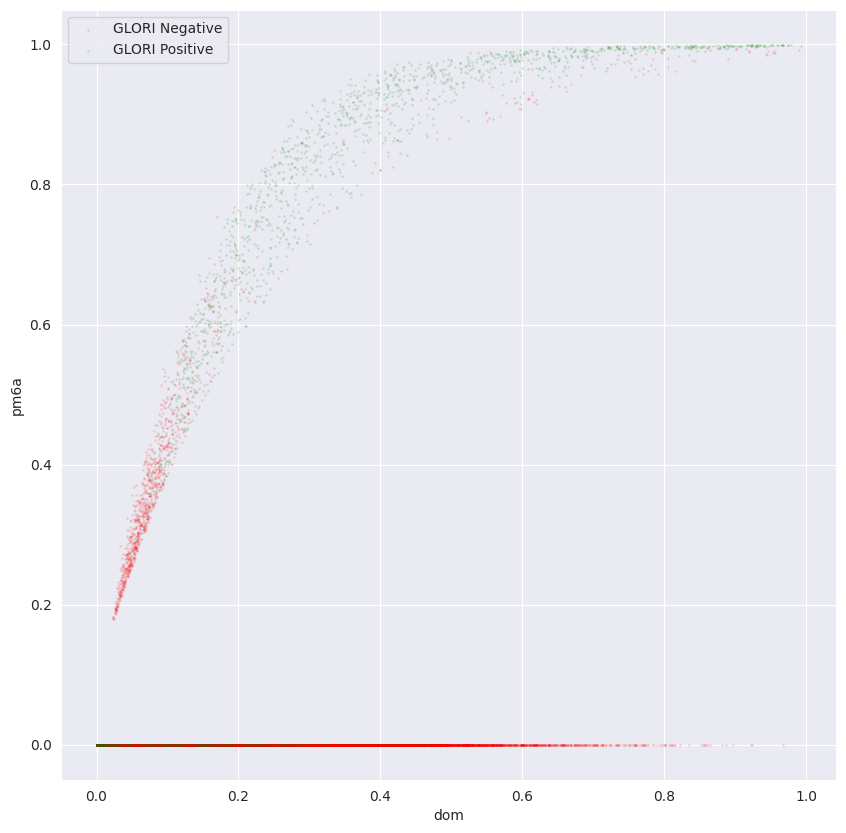

In [81]:

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a_thr"], alpha=0.1, s = 1, color="red", label="GLORI Negative")
ax.scatter(pos_df["dom"], pos_df["pm6a_thr"], alpha=0.1, s = 1, color="green", label="GLORI Positive")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()
plt.close()

In [31]:
def aggregate_pm6a(pm6a_arr):
    pm6a_arr = pm6a_arr[(pm6a_arr >= 0.98) | (pm6a_arr <= 0.1)]
    pm6a_arr = 1 - 10**(np.sum(np.log10(1 - np.clip(pm6a_arr, 0, 1-1e-20))))
    return pm6a_arr

def aggregate_dom(dom_arr):
    dom_arr = dom_arr[(dom_arr >= 0.6) | (dom_arr <= 0.2)] > 0.5
    dom_arr = np.mean(dom_arr)
    return dom_arr

test_pm6a = np.array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01])
print(aggregate_pm6a(test_pm6a))
print(aggregate_dom(test_pm6a))

test_pm6a = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.99])
print(aggregate_pm6a(test_pm6a))
print(aggregate_dom(test_pm6a))

test_pm6a = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.99, 0.99, 0.99])
print(aggregate_pm6a(test_pm6a))
print(aggregate_dom(test_pm6a))

test_pm6a = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.999])
print(aggregate_pm6a(test_pm6a))
print(aggregate_dom(test_pm6a))
    

0.09561792499119559
0.0
0.99612579511
0.1
0.9999995217031
0.3
0.999612579511
0.1


In [38]:
def import_pileup(path):
    pileup_df = pd.read_pickle(path)
    pileup_df = pileup_df[pileup_df["count_pm6a"] >= 20]
    pileup_df = pileup_df.merge(label_df_filtered, on="label_id", how="inner")
    return pileup_df

pileup_df_dict = {}
for ver in range(1,16):
    pileup_df_dict[ver] = import_pileup(f"/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v2-20240827-175235-22-373000-token_normalise_dwell_all_npz-ON0090_allmotif_pileup_test/pileup_v{ver}.pkl")


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


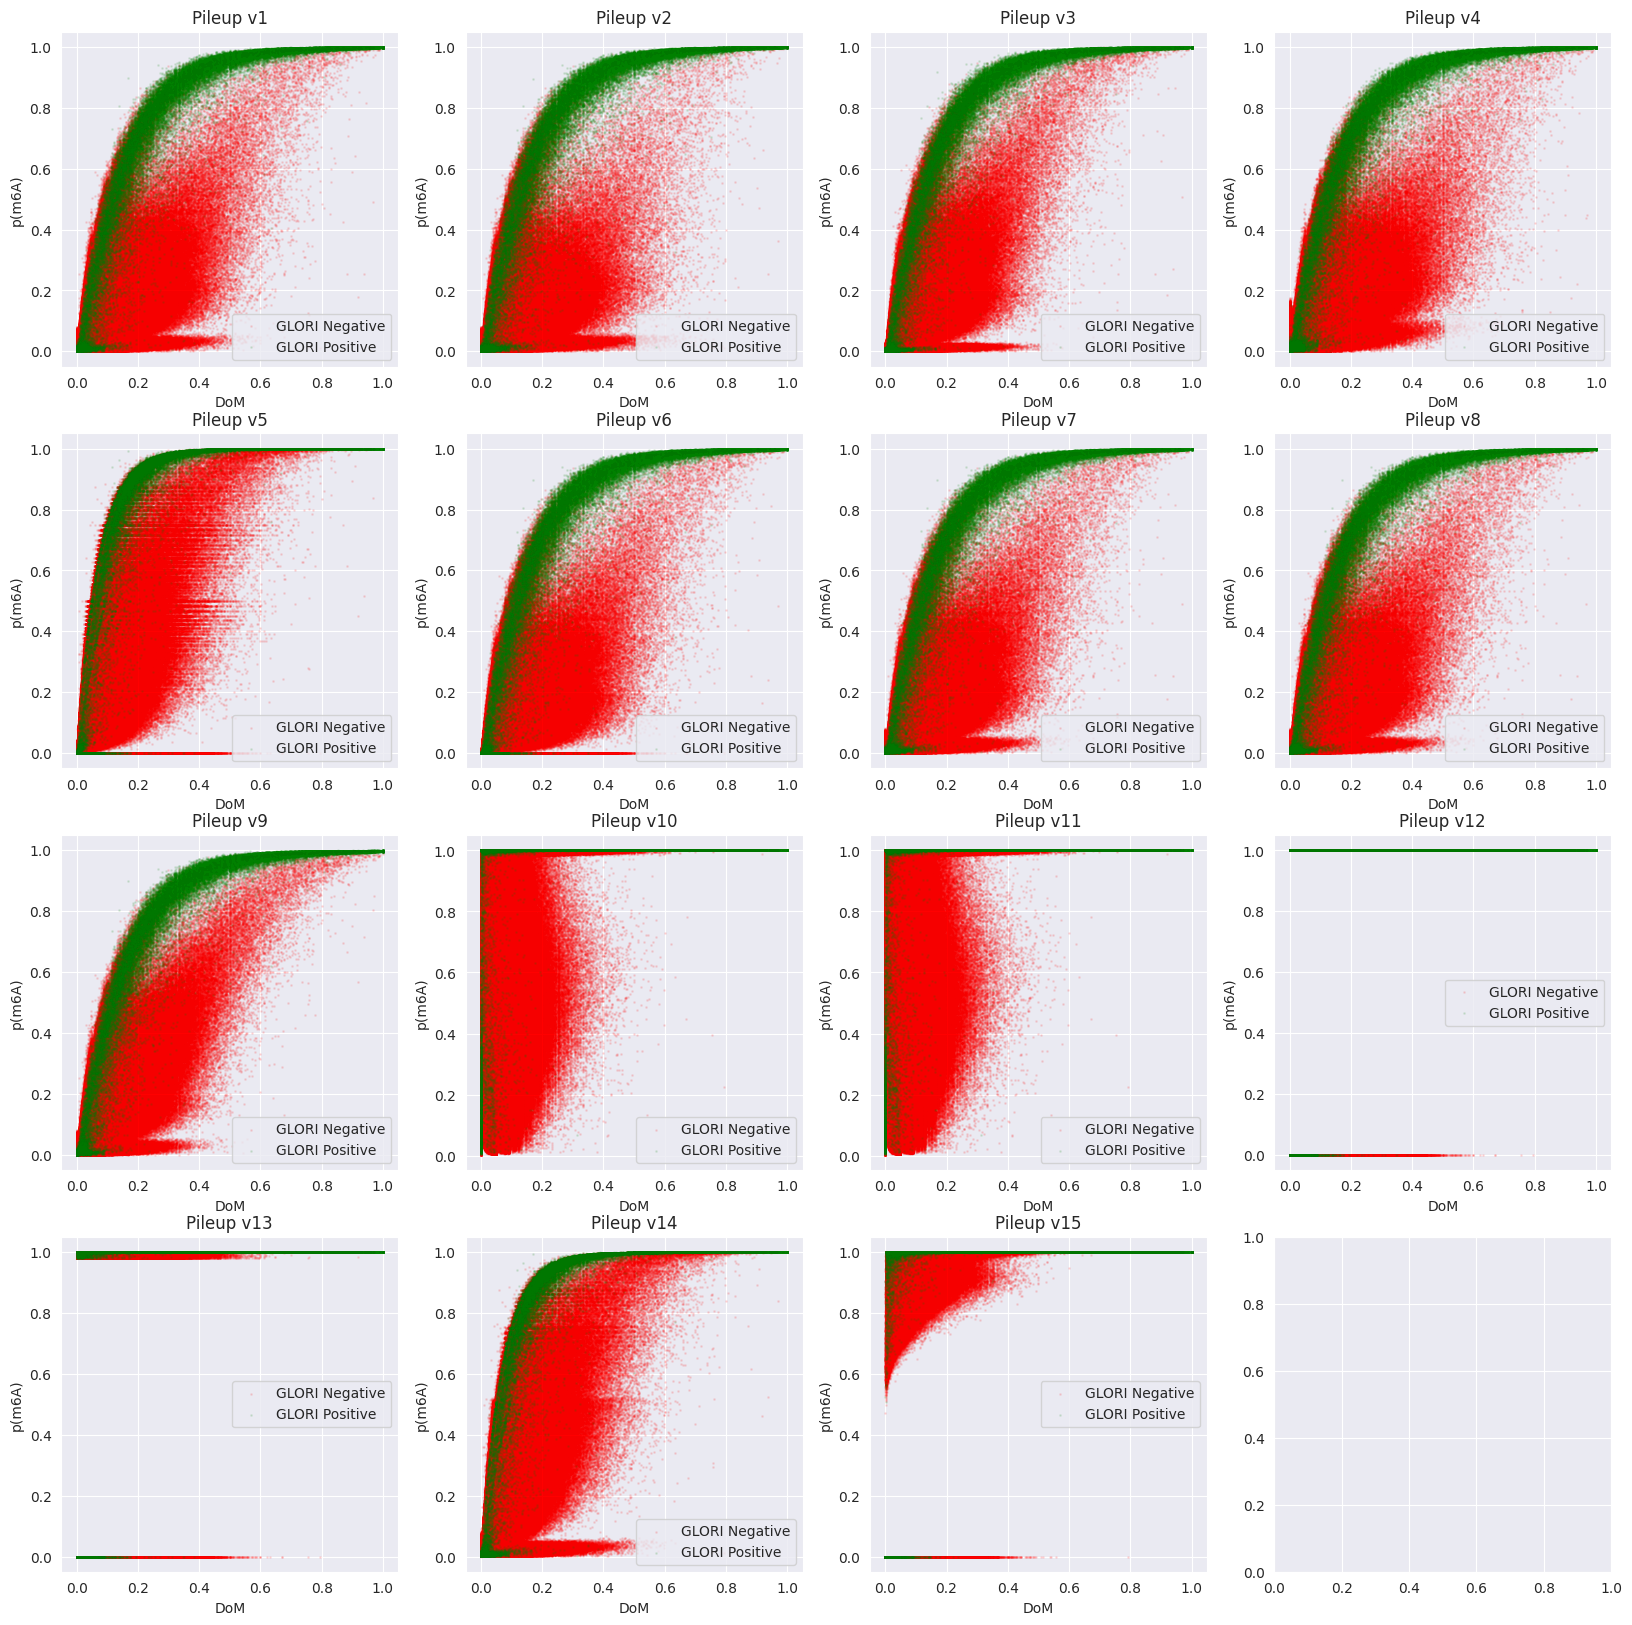

/tmp/ipykernel_17538/1707610449.py:17: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig("/extdata4/baeklab/Hyeonseo/m6A/plot/pileup.png")


KeyboardInterrupt: 

In [39]:

def plot_scatter(pileup_df_dict):

    fig, axes = plt.subplots(4, 4, figsize=(20, 20))
    
    for i, ver in tqdm.tqdm(enumerate(pileup_df_dict.keys())):
        ax = axes[i//4, i%4]
        pileup_df = pileup_df_dict[ver]
        neg_df = pileup_df[pileup_df["dom_label"] == 0]
        pos_df = pileup_df[pileup_df["dom_label"] > 0]
        ax.scatter(neg_df["dom"], neg_df["pm6a"], alpha=0.1, s=1, color="red", label="GLORI Negative")
        ax.scatter(pos_df["dom"], pos_df["pm6a"], alpha=0.1, s=1, color="green", label="GLORI Positive")
        ax.legend(loc="upper left")
        ax.set_xlabel("DoM")
        ax.set_ylabel("p(m6A)")
        ax.set_title(f"Pileup v{ver}")
    plt.show()
    fig.savefig("/extdata4/baeklab/Hyeonseo/m6A/plot/pileup.png")

plot_scatter(pileup_df_dict)

    

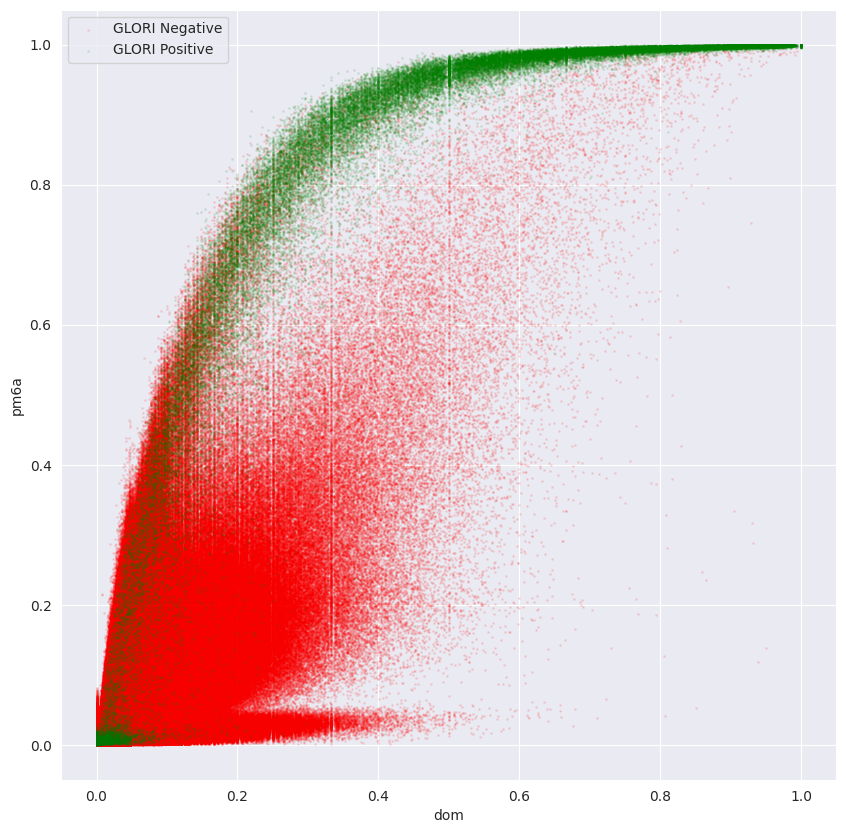

In [32]:
neg_df = cell_label_df[cell_label_df["dom_label"] == 0]
pos_df = cell_label_df[cell_label_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a"], alpha=0.1, s = 1, color="red", label="GLORI Negative")
ax.scatter(pos_df["dom"], pos_df["pm6a"], alpha=0.1, s = 1, color="green", label="GLORI Positive")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()
plt.close()

In [33]:
print(cell_label_df)

                label_id      pm6a  count_pm6a       dom  count_dom  \
0         NM_000016:1000  0.000897       257.0  0.000000        258   
1         NM_000016:1008  0.001242       254.0  0.000000        254   
2         NM_000016:1009  0.001785       257.0  0.003861        259   
3         NM_000016:1010  0.004846       247.0  0.003953        253   
4         NM_000016:1014  0.003773       248.0  0.003968        252   
...                  ...       ...         ...       ...        ...   
10220566  NR_182669:3964  0.007487        51.0  0.000000         52   
10220567  NR_182669:3965  0.005349        51.0  0.000000         53   
10220568  NR_182669:3966  0.006211        43.0  0.000000         47   
10220569  NR_182669:3968  0.005565        43.0  0.022222         45   
10220570  NR_182669:3969  0.005637        41.0  0.022727         44   

          mean_pred  depth  label  dom_label   5mer  drach  
0          0.001457    268      0        0.0  AAACT   True  
1          0.001221    26

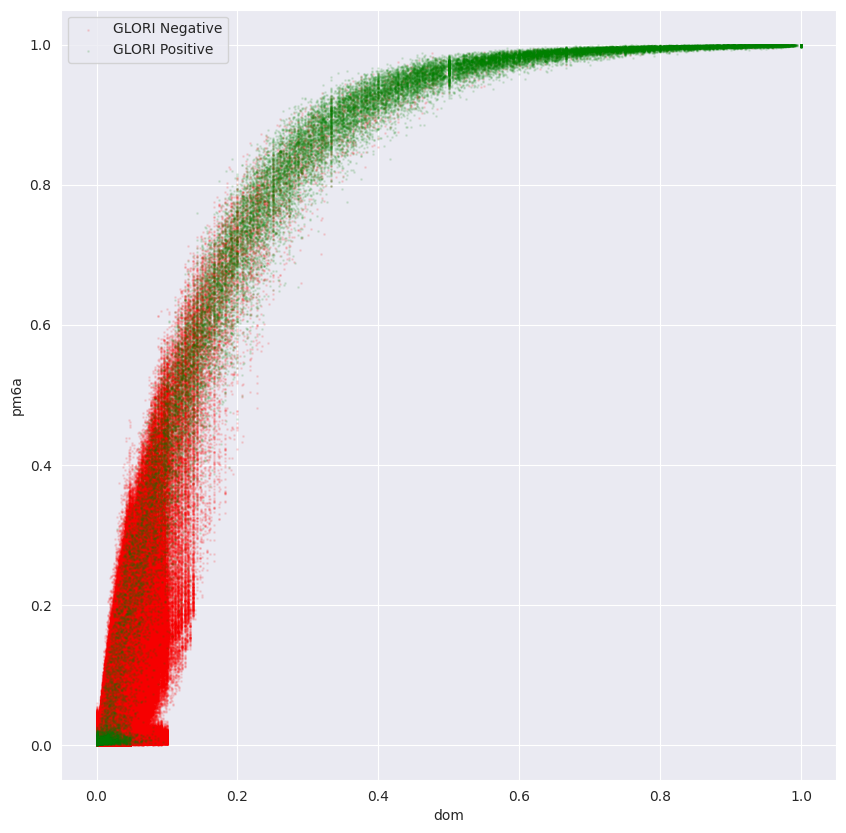

In [34]:
cell_label_df["filtered"] = (cell_label_df["count_dom"] - cell_label_df["count_pm6a"]) / cell_label_df["count_dom"]
cell_label_df_test = cell_label_df[cell_label_df["filtered"] <= 0.1]

neg_df = cell_label_df_test[cell_label_df_test["dom_label"] == 0]
pos_df = cell_label_df_test[cell_label_df_test["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a"], alpha=0.1, s = 1, color="red", label="GLORI Negative")
ax.scatter(pos_df["dom"], pos_df["pm6a"], alpha=0.1, s = 1, color="green", label="GLORI Positive")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a")
plt.show()
plt.close()

0.007352941176470588


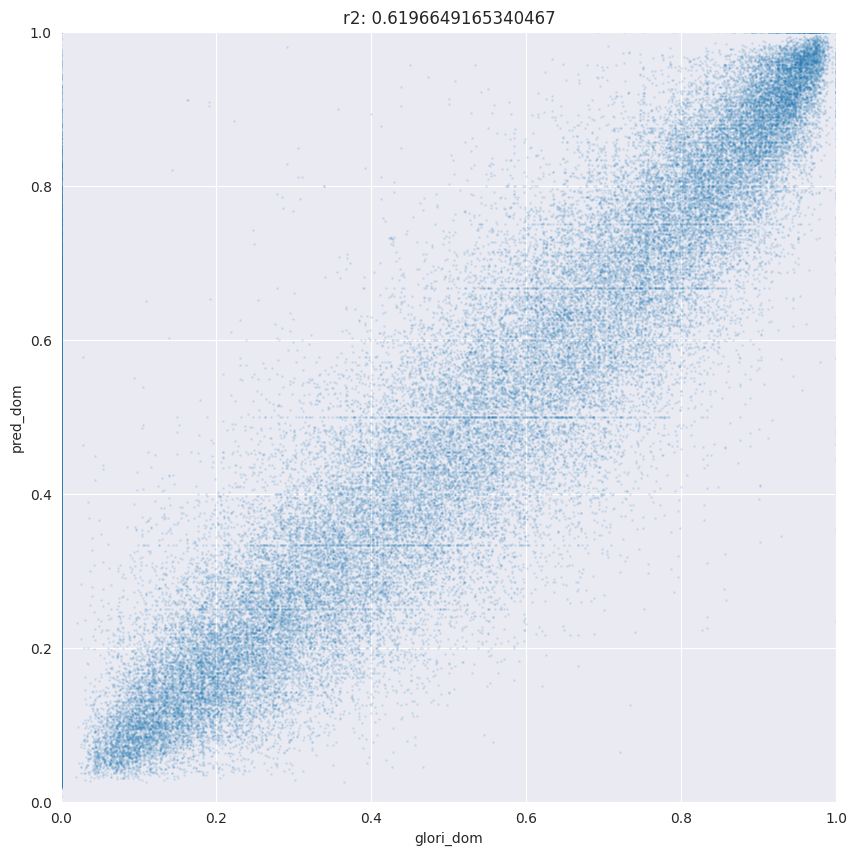

In [35]:
threshold = 0.2
selected_df = cell_label_df[cell_label_df["pm6a"] > threshold]

min_dom = selected_df["dom"].min()
print(min_dom)

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

0.01639344262295082


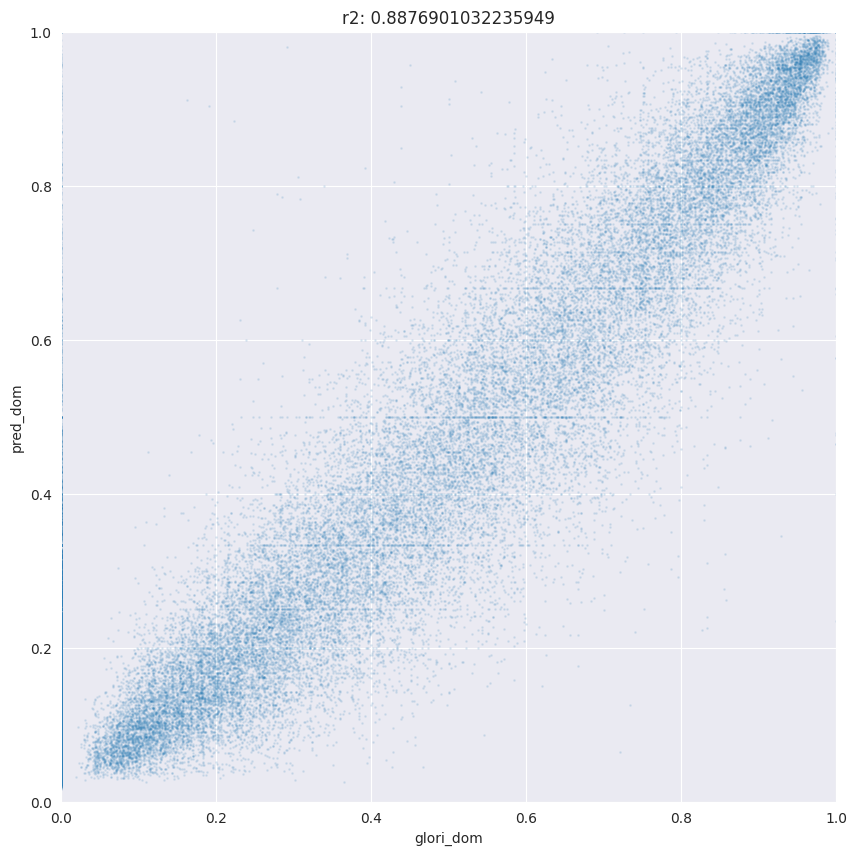

In [36]:
threshold = 0.2
selected_df = cell_label_df_test[cell_label_df_test["pm6a"] > threshold]

min_dom = selected_df["dom"].min()
print(min_dom)

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()

In [ ]:
## Plot P-R curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score


def plot_pr_curve(y_true, y_score, title):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    average_precision = average_precision_score(y_true, y_score)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.plot(recall, precision, label=f"AP: {average_precision}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    plt.show()
    plt.close()


cell_label_df = cell_label_df[cell_label_df["label"] >= 0]
plot_pr_curve(cell_label_df["label"], cell_label_df["pm6a"], "P-R curve")


0.00017838030681412772


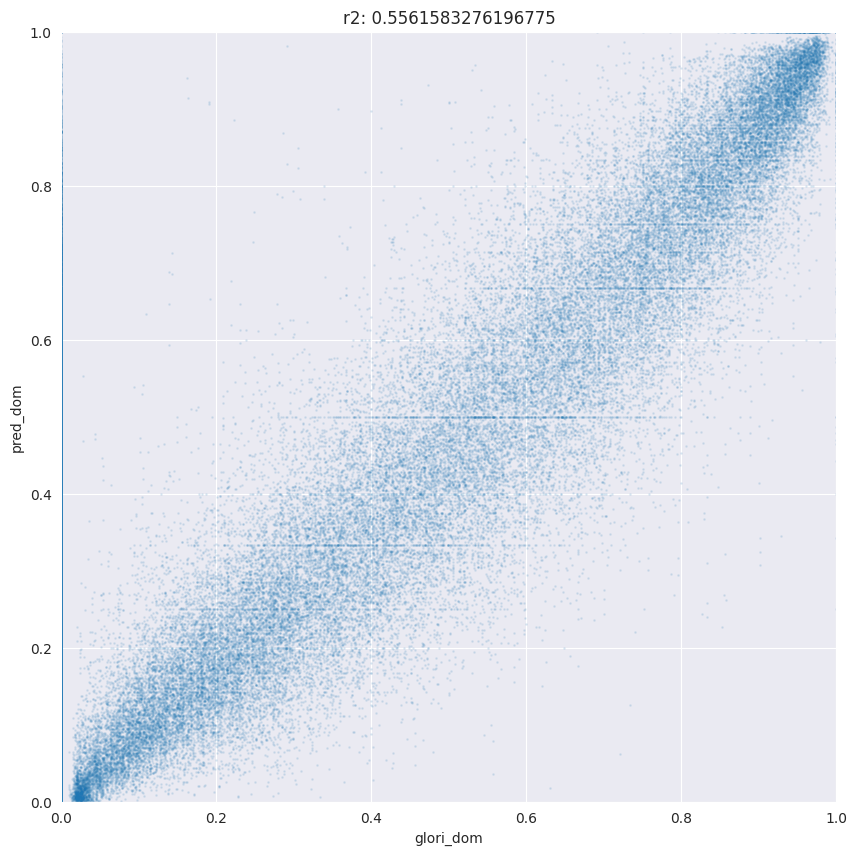

In [40]:
threshold = 0.2

selected_df = pileup_df_dict[12][pileup_df_dict[12]["pm6a"] > threshold]

min_dom = selected_df["dom"].min()
print(min_dom)

from scipy.stats import pearsonr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(selected_df["dom_label"], selected_df["dom"], alpha=0.1, s = 1)
ax.set_xlabel("glori_dom")
ax.set_ylabel("pred_dom")
r2 = pearsonr(selected_df["dom_label"], selected_df["dom"])[0] ** 2
ax.set_title(f"r2: {r2}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.show()
plt.close()